In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df=pd.read_csv("diabetes2.csv")

In [7]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size = 0.2, random_state = 0
)

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
from sklearn.naive_bayes import GaussianNB

In [14]:
model = GaussianNB()

In [17]:
model.fit(X_train, y_train)

GaussianNB()

In [21]:
Y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [23]:
accuracy = accuracy_score(y_test, Y_pred)
precision = precision_score(y_test, Y_pred, average='micro')
recall = recall_score(y_test, Y_pred, average='micro')

In [24]:
accuracy

0.7922077922077922

In [25]:
precision

0.7922077922077922

In [26]:
recall

0.7922077922077922

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, Y_pred)

print(cm)

[[93 14]
 [18 29]]


In [29]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

In [30]:
IQR

,0
Pregnancies,5.0000
Glucose,41.2500
BloodPressure,18.0000
SkinThickness,32.0000
Insulin,127.2500
BMI,9.3000
DiabetesPedigreeFunction,0.3825
Age,17.0000
Outcome,1.0000


In [31]:
df_no_outlier = df[~((df < (Q1 - 1.5 * IQR)) |
                    (df > (Q3 + 1.5 * IQR))).any(axis=1)]

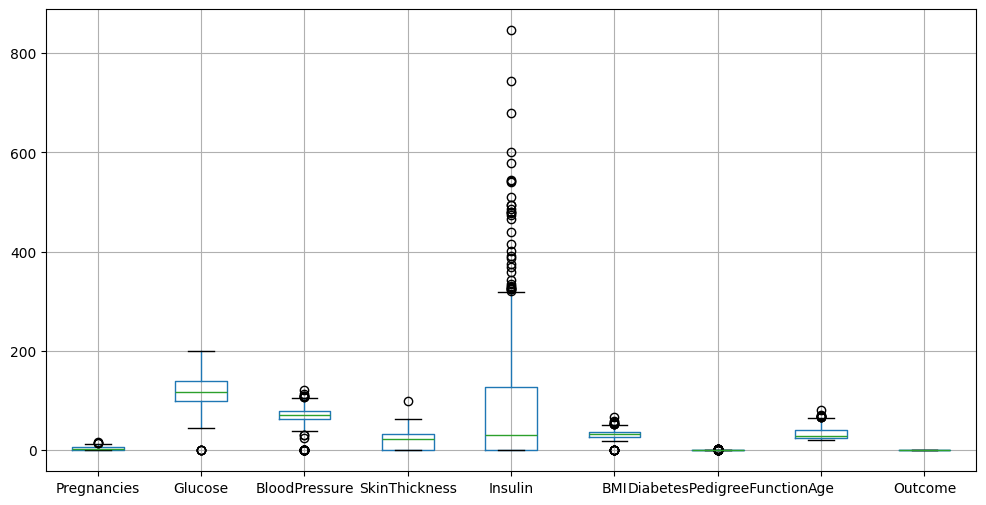

In [32]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))
plt.show()